In [1]:
import os
import pandas as pd

# パスを正しく展開
file_path = os.path.expanduser('~/Documents/soturon/HR/Time_Series_20080105_1228_corrected.d')

# テキストファイルをスペース区切りとしてDataFrameに変換
df = pd.read_csv(file_path, delimiter=r'\s+', header=None)

# 1列目に-1が出るまでを1つのレースとしてデータを分割
race_indices = df[df[0] == -1].index

Int64Index([    54,    112,    189,    235,    318,    360,    428,    494,
               570,    640,
            ...
            321774, 321826, 321852, 321882, 321943, 321971, 322049, 322088,
            322123, 322197],
           dtype='int64', length=3450)


In [2]:
races_list = []

start_idx = 0
for i, idx in enumerate(race_indices):
    race_df = df.iloc[start_idx:idx]
    races_list.append(race_df)
    start_idx = idx + 1

In [3]:
vote_list = []
odds_list = []

for i, race_df in enumerate(races_list):
    # オッズの計算
    odds_df = race_df.iloc[1:,2:]
    odds_df = odds_df.loc[:, (odds_df != 0).any(axis=0)]# odds_dfの内、列が全て０の列を削除
    odds_list.append(odds_df)

    # 得票率の計算
    vote_df = 0.8 / odds_df.replace(0, float('inf')) #オッズの逆数を取り、0の場合はinfに置き換えてから0.8を掛ける
    vote_df[odds_df == 0] = 0
    vote_df = vote_df.loc[:, (vote_df != 0).any(axis=0)]# vote_dfの内、列が全て０の列を削除
    vote_list.append(vote_df)

In [4]:
# 各行の0以外の最小値に0.05を加える処理
def add_to_minimum(row):
    # 0以外の要素をフィルタリング
    non_zero_values = row[row != 0]

    # 0以外の最小値が存在する場合のみ処理
    if not non_zero_values.empty:
        # 0以外の最小値を取得
        min_index = non_zero_values.idxmin()  # 最小値のインデックス
        row[min_index] += 0.05  # 0.05を加算
    return row

# データフレームに処理を適用
odds_df = odds_df.apply(add_to_minimum, axis=1)

In [5]:
correct_odds_list = []
correct_vote_list = []

for j, race_df in enumerate(races_list):
    # オッズの計算
    odds_df = race_df.iloc[1:,2:]
    odds_df = odds_df.loc[:, (odds_df != 0).any(axis=0)]# odds_dfの内、列が全て０の列を削除
    odds_df = odds_df.apply(add_to_minimum, axis=1)
    correct_odds_list.append(odds_df)

    # 得票率の計算
    vote_df = 0.8 / odds_df.replace(0, float('inf')) #オッズの逆数を取り、0の場合はinfに置き換えてから0.8を掛ける
    vote_df[odds_df == 0] = 0
    vote_df = vote_df.loc[:, (vote_df != 0).any(axis=0)]# vote_dfの内、列が全て０の列を削除
    correct_vote_list.append(vote_df)

In [6]:
# 行数を指定
length = 20

# 行数が20未満のデータフレームをカウント
count_under_length = sum(df.shape[0] < length for df in correct_odds_list)

print("行数が"f"{length}""未満のデータフレームの数:", count_under_length)

# 行数が20未満のデータフレームのインデックスを取得
indices_under_length = [index for index, df in enumerate(correct_odds_list) if df.shape[0] < length]

print("行数が"f"{length}""未満のデータフレームのインデックス:", indices_under_length)

行数が20未満のデータフレームの数: 3
行数が20未満のデータフレームのインデックス: [2445, 2757, 2758]


In [7]:
# 行数がlength未満のデータフレームを除外した新しいリストを作成
filtered_odds_list_length = [df for df in correct_odds_list if df.shape[0] >= length]
filtered_vote_list_length = [df for df in correct_vote_list if df.shape[0] >= length]

# 結果の確認
print(f"元のリストのデータフレーム数: {len(correct_odds_list)}")
print(f"新しいリストのデータフレーム数: {len(filtered_odds_list_length)}")
print(f"新しいリストのデータフレーム数: {len(filtered_vote_list_length)}")

元のリストのデータフレーム数: 3450
新しいリストのデータフレーム数: 3447
新しいリストのデータフレーム数: 3447


In [8]:
import numpy as np

# 新しいリストを初期化
odds_per_list = []
# 各データフレームに対して処理
for df in filtered_odds_list_length:
    # データフレームのインデックスの長さを取得
    num_rows = len(df)

    # 5%刻みのインデックスを計算
    percentage_indices = np.linspace(0, num_rows - 1, num= length+1 , dtype=int)  # 0%から100%まで5%刻み

    # 重複を避けるためにユニークなインデックスにする
    percentage_indices = sorted(set(percentage_indices))

    # インデックスに基づいてデータを取り出し、新しいデータフレームとして格納
    extracted_rows = df.iloc[percentage_indices].reset_index(drop=True)

    # 結果をリストに追加
    odds_per_list.append(extracted_rows)

In [9]:
import numpy as np

# 新しいリストを初期化
vote_per_list = []
# 各データフレームに対して処理
for df in filtered_vote_list_length:
    # データフレームのインデックスの長さを取得
    num_rows = len(df)

    # 5%刻みのインデックスを計算
    percentage_indices = np.linspace(0, num_rows - 1, length+1 , dtype=int)  # 0%から100%まで5%刻み

    # 重複を避けるためにユニークなインデックスにする
    percentage_indices = sorted(set(percentage_indices))

    # インデックスに基づいてデータを取り出し、新しいデータフレームとして格納
    extracted_rows = df.iloc[percentage_indices].reset_index(drop=True)

    # 結果をリストに追加
    vote_per_list.append(extracted_rows)

In [10]:
import numpy as np

list = np.array([])

for vote_df in vote_per_list :
    list = np.append(list ,vote_df.iloc[-1, :].values)

print(list.reshape(1, -1))
print(list.shape)

list.sort()

# 後ろから順に1000ずつ分割する
split_data = [list[::-1][i:i + 1000] for i in range(0, len(list), 1000)]

# 各分割リストを元の順序に戻す
split_data = [chunk[::-1] for chunk in split_data]

# リスト全体の順序を後ろから前に分割した順序にする
split_data.reverse()

[[0.02185792 0.21621622 0.00749064 ... 0.015625   0.01965602 0.00566572]]
(50273,)


In [11]:
import pandas as pd

# 横方向に結合
combined_vote_df = pd.concat(vote_per_list, axis=1)

# 結合されたDataFrameを表示
print(combined_vote_df.shape)

(21, 50273)


In [15]:
print(combined_vote_df)
vote_array = np.array(combined_vote_df)

          2         3         4         5         6         7         8   \
0   0.258065  0.280702  0.000000  0.000000  0.000000  0.103896  0.103896   
1   0.017021  0.202532  0.003929  0.000000  0.160000  0.105263  0.065041   
2   0.014388  0.183908  0.005483  0.015748  0.160000  0.117647  0.047059   
3   0.032000  0.153846  0.007759  0.017058  0.155340  0.095238  0.042328   
4   0.029304  0.149533  0.007992  0.019950  0.145455  0.086957  0.042553   
5   0.023188  0.163265  0.009840  0.017778  0.188235  0.077670  0.042781   
6   0.021739  0.156863  0.010884  0.020619  0.175824  0.080808  0.040816   
7   0.021164  0.148148  0.010695  0.021164  0.161616  0.082474  0.038278   
8   0.020101  0.152381  0.013245  0.024845  0.137931  0.080808  0.036697   
9   0.038278  0.146789  0.012780  0.025559  0.125000  0.095238  0.042328   
10  0.038278  0.136752  0.014545  0.038095  0.123077  0.094118  0.051948   
11  0.043956  0.131148  0.015504  0.045455  0.119403  0.087912  0.057143   
12  0.043716

In [14]:
print(vote_array)

[[0.25806452 0.28070175 0.         ... 0.         0.         0.        ]
 [0.01702128 0.20253165 0.00392927 ... 0.05970149 0.025      0.0042328 ]
 [0.01438849 0.18390805 0.00548321 ... 0.04060914 0.02877698 0.00380409]
 ...
 [0.03212851 0.13114754 0.01296596 ... 0.02318841 0.02461538 0.00779727]
 [0.01793722 0.19512195 0.00965018 ... 0.02105263 0.02139037 0.00729262]
 [0.02185792 0.21621622 0.00749064 ... 0.015625   0.01965602 0.00566572]]


In [19]:
import numpy as np

# 各列の最後の行（21行目）の値を取得
last_row_values = vote_array[-1, :]  # -1で最後の行を取得

# 各列を最後の行の値でソートするためのインデックスを取得
sorted_indices = np.argsort(last_row_values)

# 列をソート
sorted_vote_array = vote_array[:, sorted_indices]

# ソート後に各列の21行目の値を取得
row_21_values = sorted_vote_array[20, :]

In [23]:
print(vote_array[20,:])
print(sum(row_21_values == 0.0))

[0.02185792 0.21621622 0.00749064 ... 0.015625   0.01965602 0.00566572]
138


In [24]:
# row_21_values が 0 の列を除外
non_zero_indices = np.where(row_21_values != 0)[0]  # 0以外の列インデックスを取得
filtered_vote_array = sorted_vote_array[:, non_zero_indices]
filtered_row_21_values = row_21_values[non_zero_indices]
print(sum(filtered_row_21_values == 0.0))

difference_array = filtered_vote_array - filtered_row_21_values  

0


In [30]:
difference_array[:, 1000]

array([-0.00252765, -0.00082443, -0.00017263,  0.00172994,  0.00084788,
        0.00105017,  0.00190203,  0.00088241,  0.00100125,  0.00291453,
        0.00279504,  0.00251649,  0.00271138,  0.0040459 ,  0.00422911,
        0.00447761,  0.00442283,  0.00348739,  0.00348287,  0.00106948,
        0.        ])

In [32]:
# filtered_row_21_values を2次元配列に変換
filtered_row_21_values_2d = filtered_row_21_values[np.newaxis, :]

# result_array と filtered_row_21_values を結合
final_array = np.vstack((difference_array, filtered_row_21_values_2d))

print(final_array.shape)


(22, 50135)


In [157]:
print(sum(final_array[21,:] > 0.69))

14


In [158]:
split_list = []

for lower_bound in np.arange(0, 0.7, 0.01):
    upper_bound = lower_bound + 0.01

    mask = (final_array[-1,:] >= lower_bound) & (final_array[-1,:] < upper_bound)
    selected_array = final_array[:, mask]
    split_list.append(selected_array)

In [163]:
split_list[0].shape

(22, 12791)

In [167]:
split_list_mean = [np.mean(array, axis=1) for array in split_list]
print(split_list_mean[0].shape)

(22,)


In [169]:
split_list_mean[0].tolist()

[0.00941004561352388,
 0.008042010912179565,
 0.0075257668494763084,
 0.007212180593980326,
 0.007030287623254762,
 0.006942432788140793,
 0.006961532472023422,
 0.006894752994894731,
 0.006807836069773007,
 0.006720967987162096,
 0.006642754665846943,
 0.006563659311623512,
 0.006508868475587383,
 0.0064207855484126174,
 0.006289108909881681,
 0.006115310368561358,
 0.005934397366498107,
 0.005483309779728668,
 0.00486131286709552,
 0.0036706298100133796,
 0.0,
 0.005609558670080393]

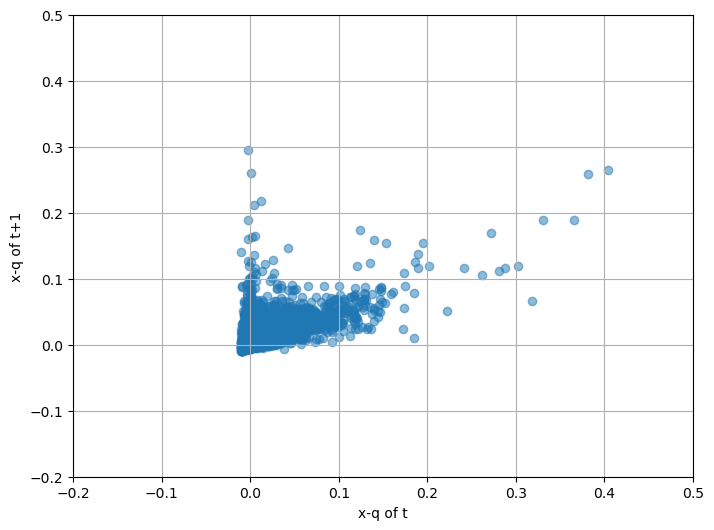

In [438]:
import matplotlib.pyplot as plt

x = split_list[0][1,:]
y = split_list[0][2,:]

plt.figure(figsize=(8, 6))
plt.scatter(x,y,alpha=0.5)
plt.xlabel("x-q of t")
plt.ylabel("x-q of t+1")
plt.xlim(-0.2, 0.5)
plt.ylim(-0.2, 0.5)
plt.grid(True)
plt.show()

In [274]:
for i in range(0,70):
    if len(split_list[i][19,:]) == 0:
        print(i)

38
40
42
44
46
47
49
50
52
53
54
56
57
58
60
61
62
63
65
66
67
68


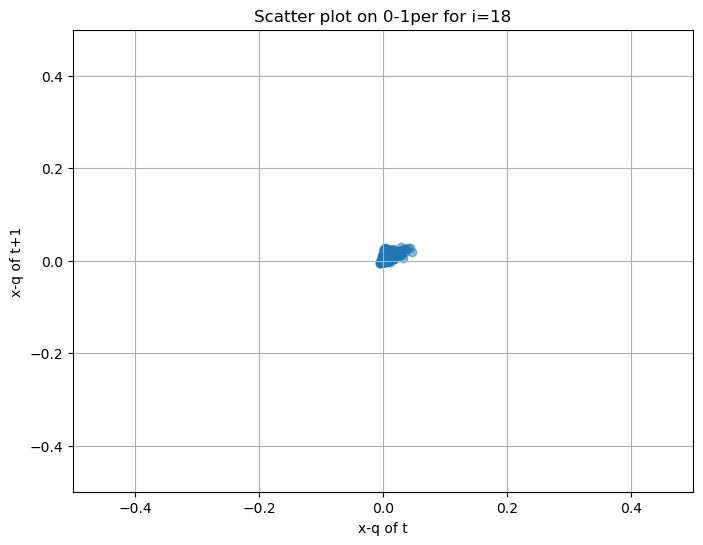

In [464]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[0][i, :]
    y = split_list[0][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 0-1per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_0-1.gif", writer="pillow")
plt.show()

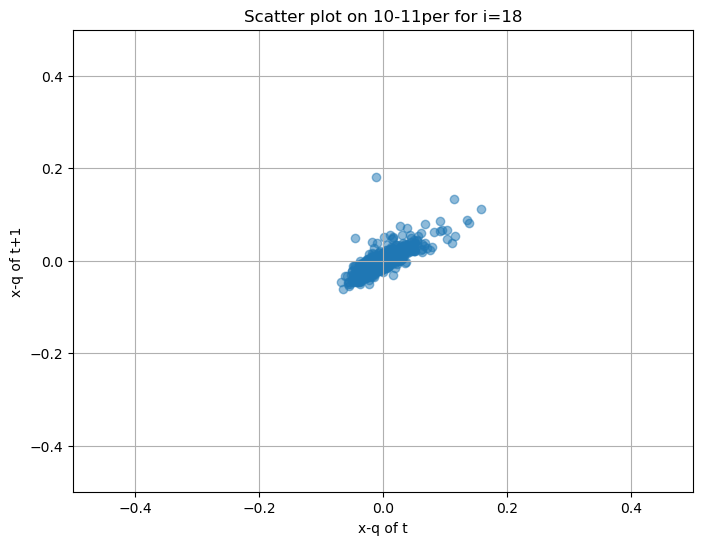

In [465]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[10][i, :]
    y = split_list[10][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 10-11per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_10-11.gif", writer="pillow")
plt.show()

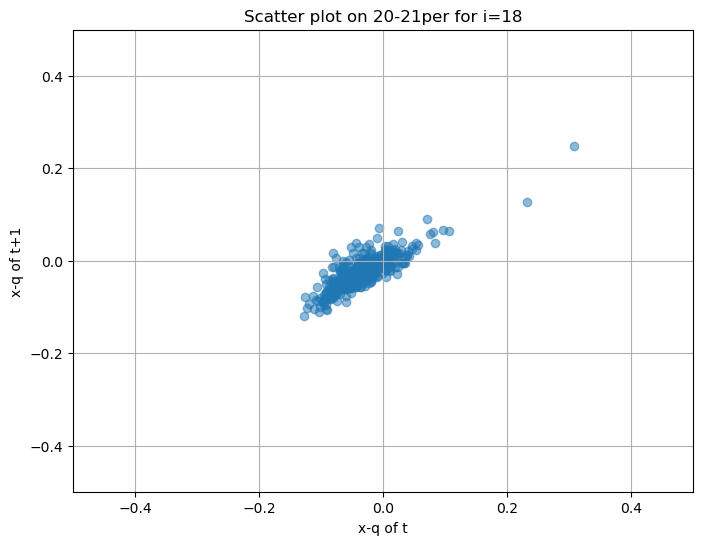

In [466]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[20][i, :]
    y = split_list[20][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 20-21per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_20-21.gif", writer="pillow")
plt.show()

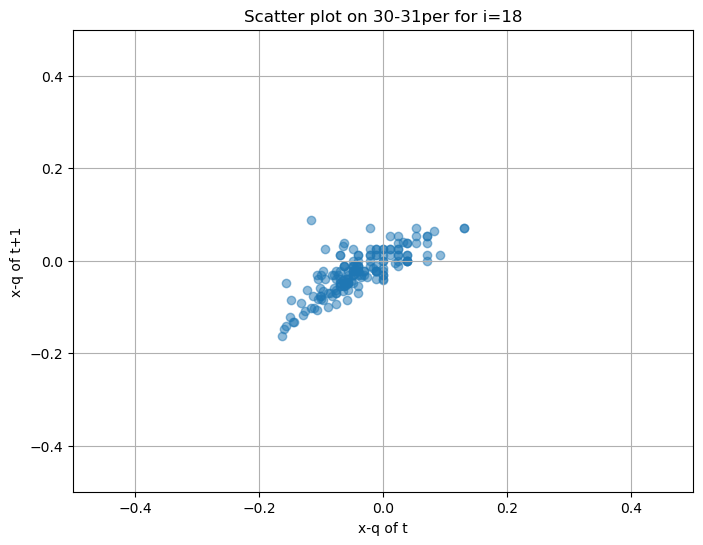

In [467]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[30][i, :]
    y = split_list[30][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 30-31per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_30-31.gif", writer="pillow")
plt.show()

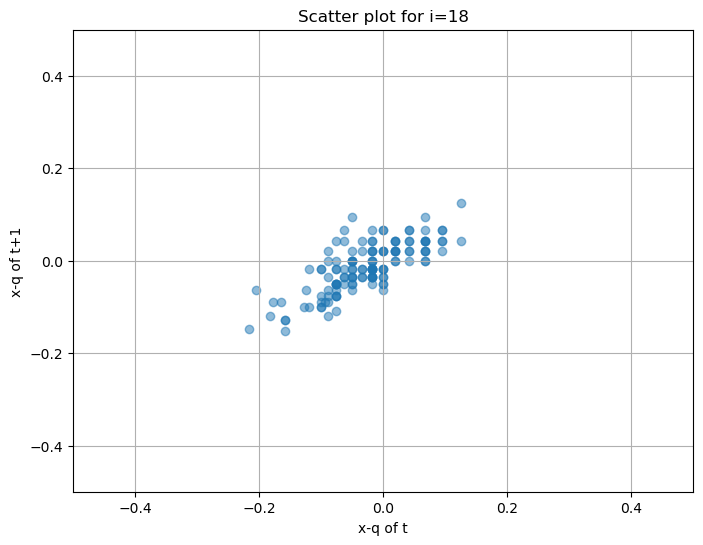

In [468]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[39][i, :]
    y = split_list[39][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_39-40.gif", writer="pillow")
plt.show()

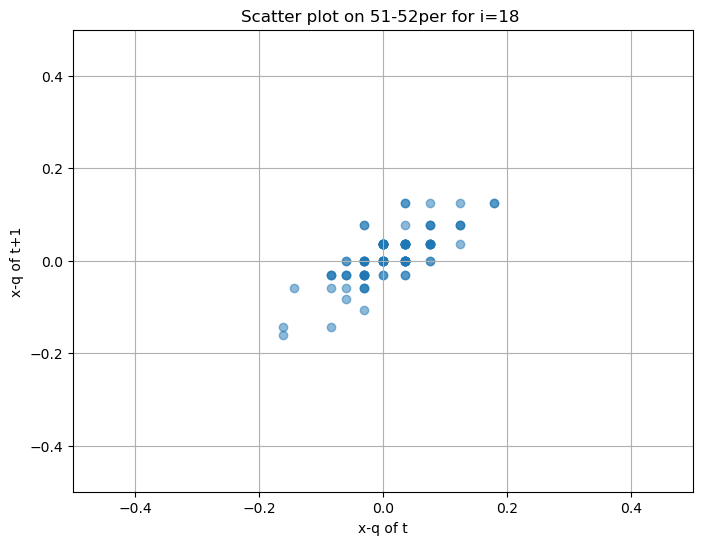

In [469]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[51][i, :]
    y = split_list[51][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 51-52per for i={i} ")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_51-52.gif", writer="pillow")
plt.show()

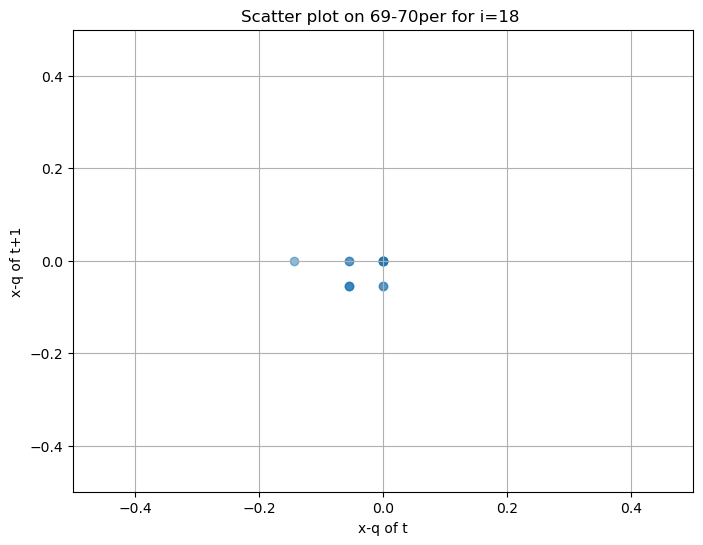

In [470]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[69][i, :]
    y = split_list[69][i + 1, :]
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("x-q of t+1")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 69-70per for i={i} ")

ani = animation.FuncAnimation(fig, update, frames=range(0, 19), repeat=False)
ani.save("scatter_plot_69-70.gif", writer="pillow")
plt.show()

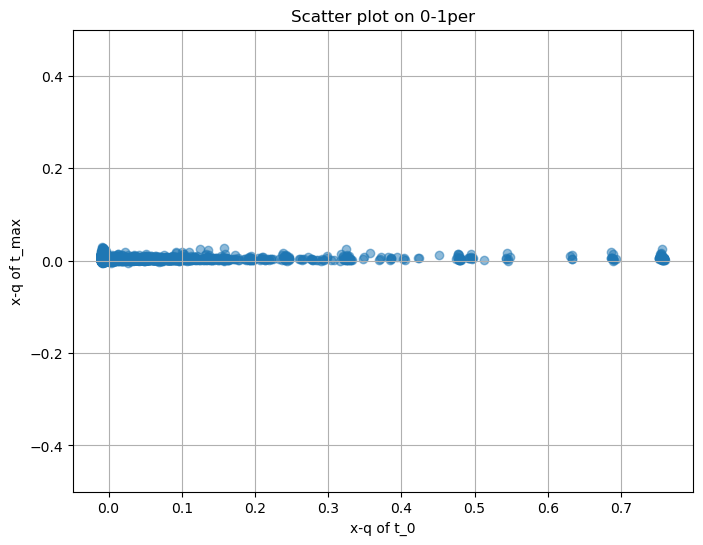

In [ ]:
x = split_list[0][0,:]
y = split_list[0][19,:]

plt.figure(figsize=(8, 6))
plt.scatter(x,y,alpha=0.5)
plt.xlabel("x-q of t_0")
plt.ylabel("x-q of t_max")
plt.title("Scatter plot on 0-1per")
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.show()

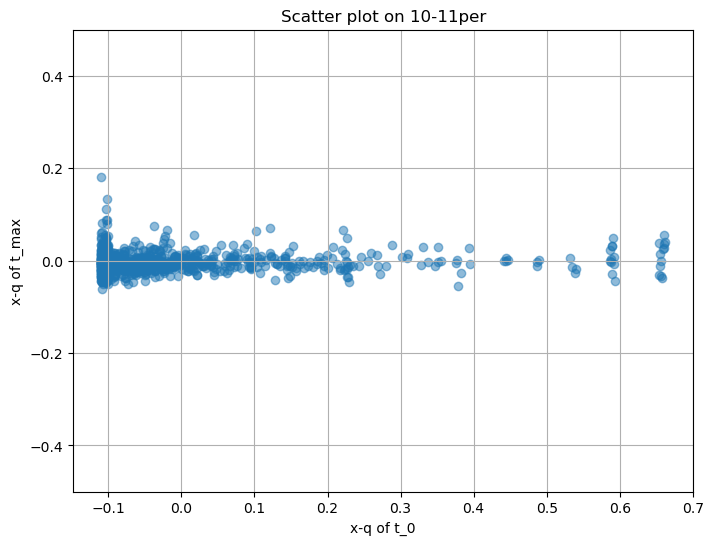

In [461]:
x = split_list[10][0,:]
y = split_list[10][19,:]

plt.figure(figsize=(8, 6))
plt.scatter(x,y,alpha=0.5)
plt.xlabel("x-q of t_0")
plt.ylabel("x-q of t_max")
plt.title("Scatter plot on 10-11per")
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.show()

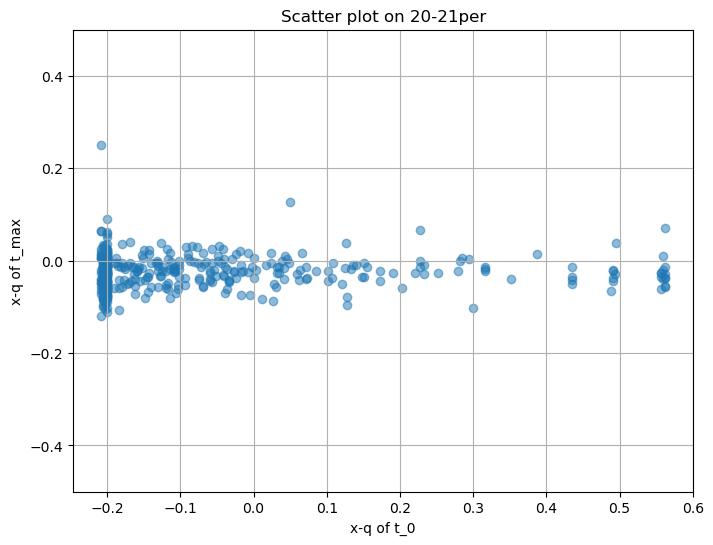

In [462]:
x = split_list[20][0,:]
y = split_list[20][19,:]

plt.figure(figsize=(8, 6))
plt.scatter(x,y,alpha=0.5)
plt.xlabel("x-q of t_0")
plt.ylabel("x-q of t_max")
plt.title("Scatter plot on 20-21per")
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.show()

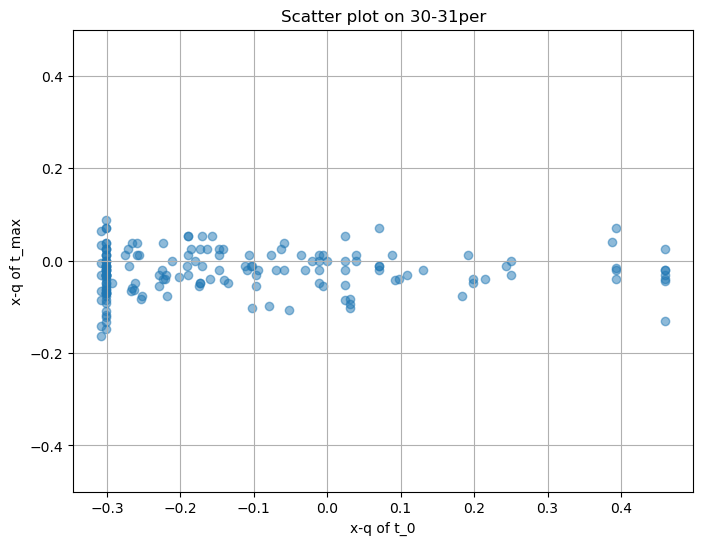

In [463]:
x = split_list[30][0,:]
y = split_list[30][19,:]

plt.figure(figsize=(8, 6))
plt.scatter(x,y,alpha=0.5)
plt.xlabel("x-q of t_0")
plt.ylabel("x-q of t_max")
plt.title("Scatter plot on 30-31per")
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.show()

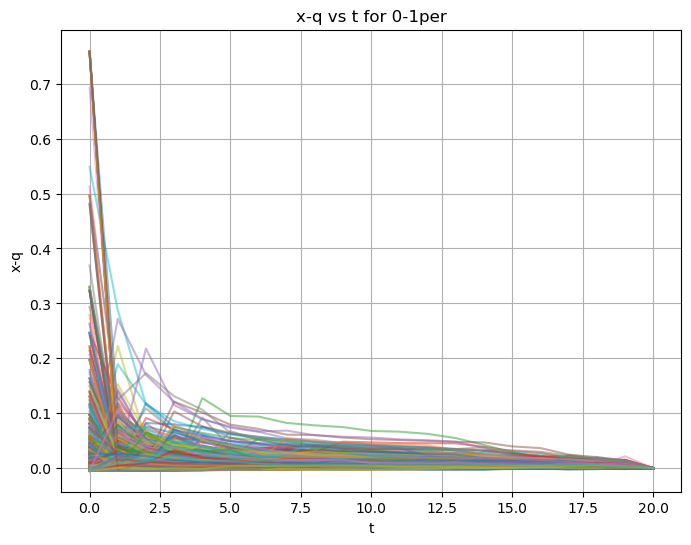

In [392]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(5000):
    y = split_list[0][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 0-1per")
plt.grid(True)
plt.show()

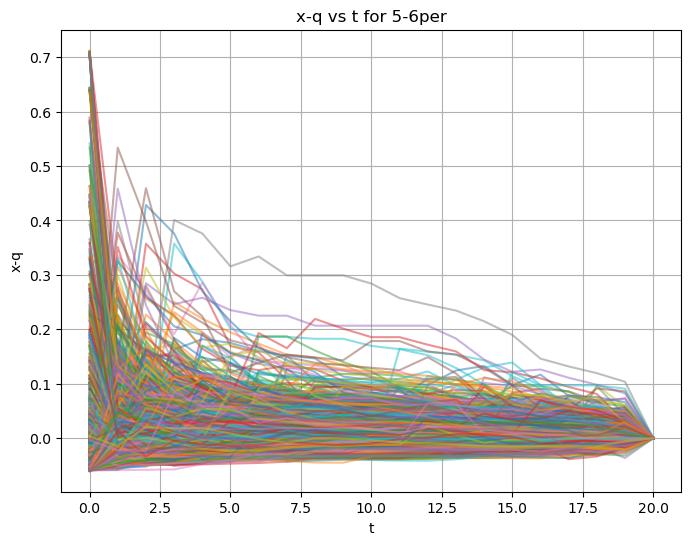

In [395]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(2279):
    y = split_list[5][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 5-6per")
plt.grid(True)
plt.show()

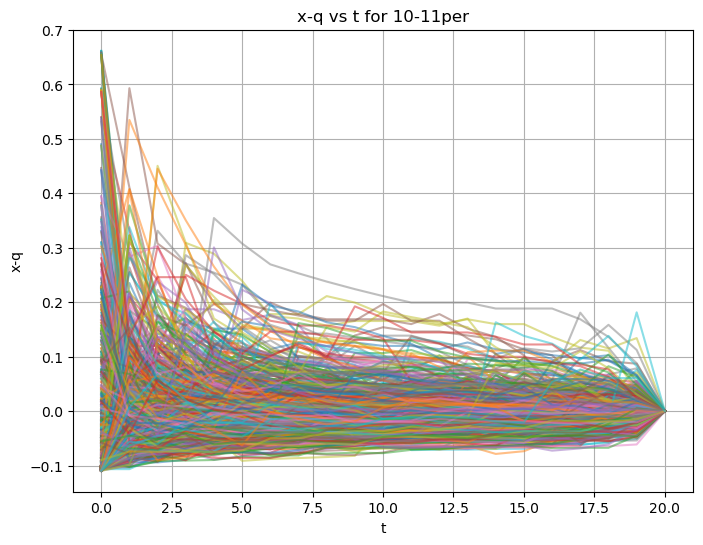

In [389]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(1070):
    y = split_list[10][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 10-11per")
plt.grid(True)
plt.show()

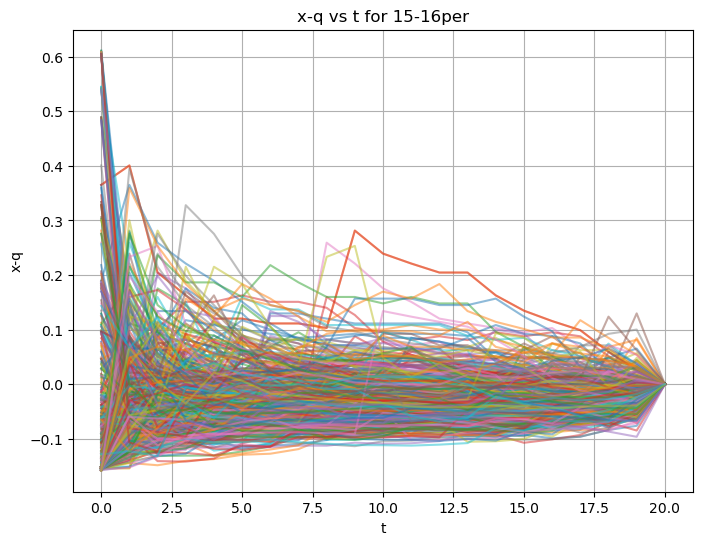

In [397]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(550):
    y = split_list[15][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 15-16per")
plt.grid(True)
plt.show()

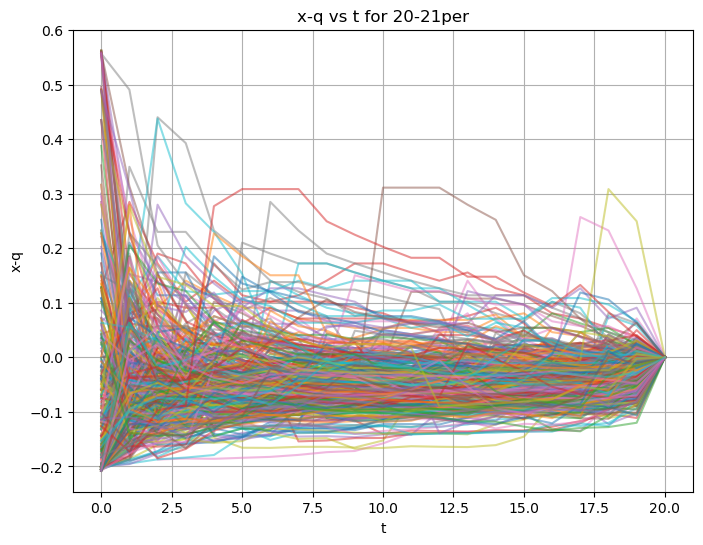

In [399]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(410):
    y = split_list[20][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 20-21per")
plt.grid(True)
plt.show()

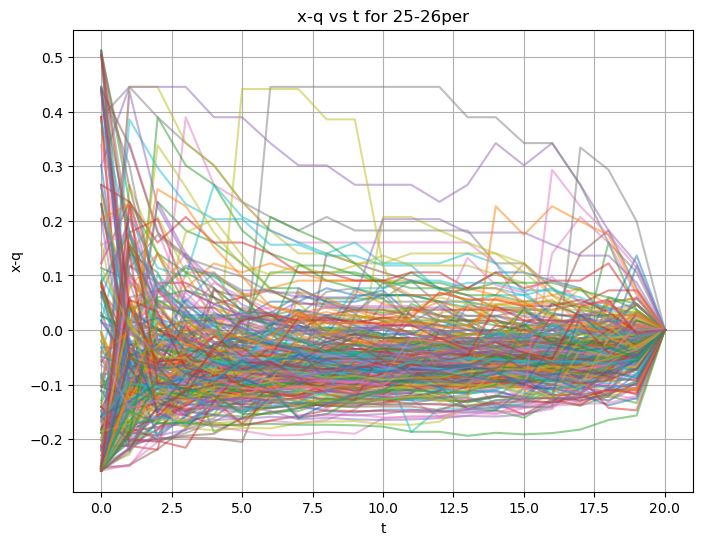

In [386]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(266):
    y = split_list[25][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 25-26per")
plt.grid(True)
plt.show()

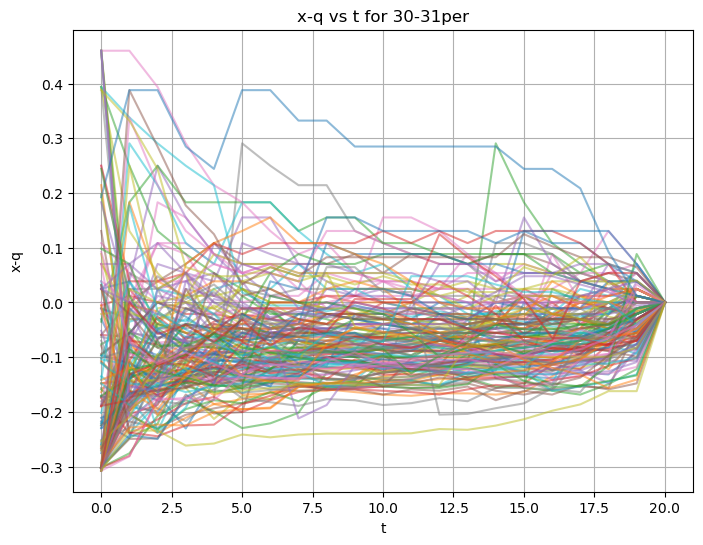

In [402]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(169):
    y = split_list[30][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 30-31per")
plt.grid(True)
plt.show()

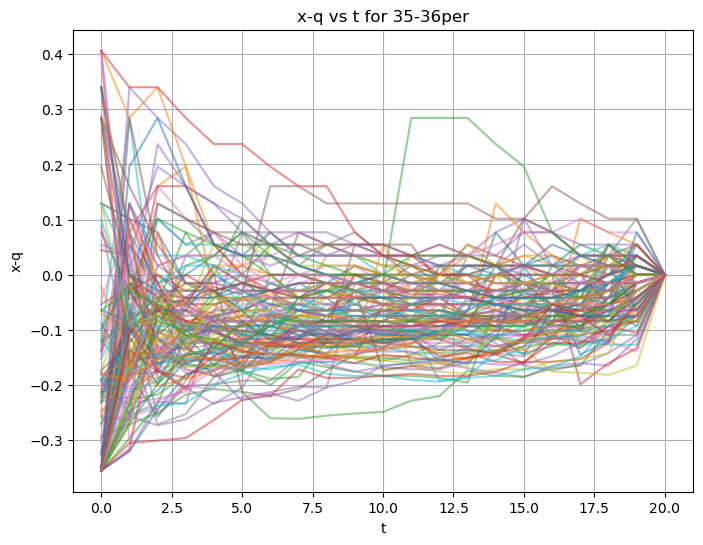

In [404]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(137):
    y = split_list[35][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 35-36per")
plt.grid(True)
plt.show()

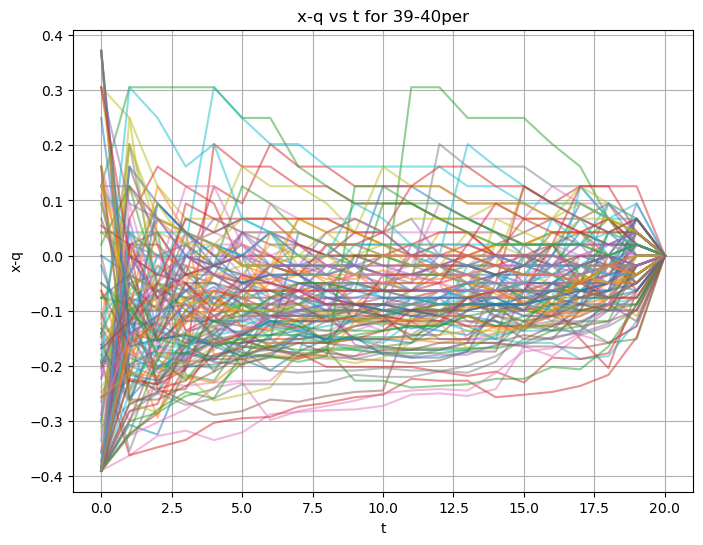

In [406]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(135):
    y = split_list[39][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 39-40per")
plt.grid(True)
plt.show()

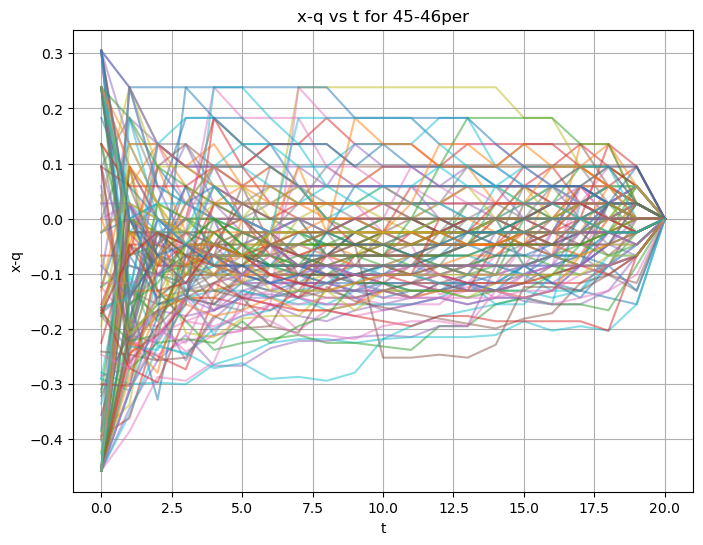

In [408]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(131):
    y = split_list[45][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 45-46per")
plt.grid(True)
plt.show()

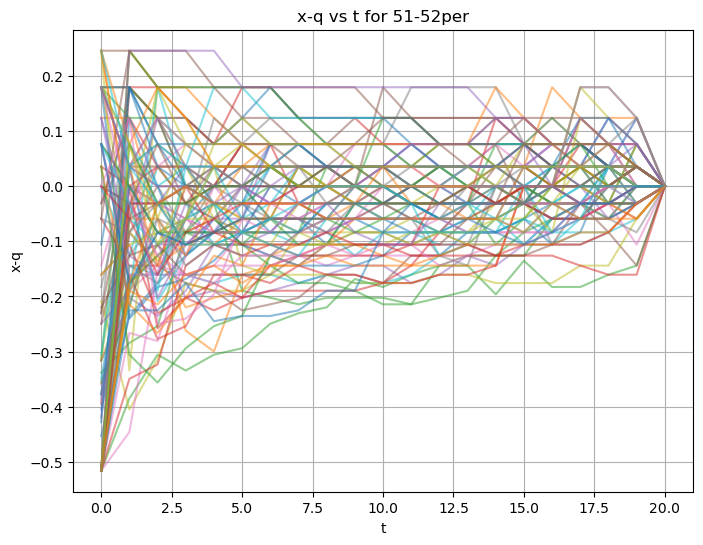

In [385]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(102):
    y = split_list[51][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 51-52per")
plt.grid(True)
plt.show()

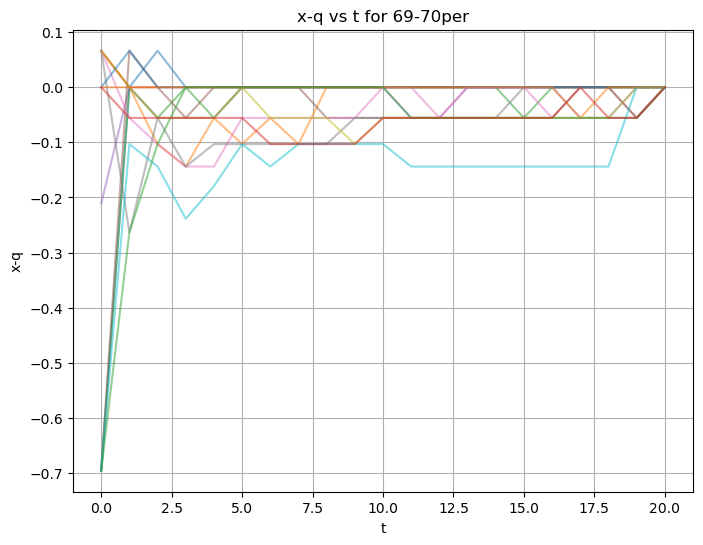

In [411]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(14):
    y = split_list[69][0:21,i]
    plt.plot(t,y,alpha=0.5)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 69-70per")
plt.grid(True)
plt.show()

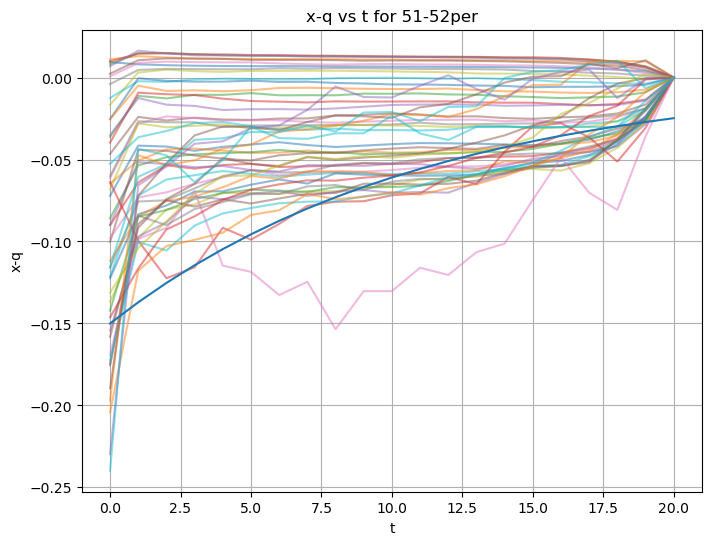

In [526]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)
for i in range(0,70):
    y = np.mean(split_list[i][0:21,:], axis=1)
    plt.plot(t,y,alpha=0.5)

x = -0.15*np.exp(-0.09*t)
plt.plot(t,x)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 51-52per")
plt.grid(True)
plt.show()

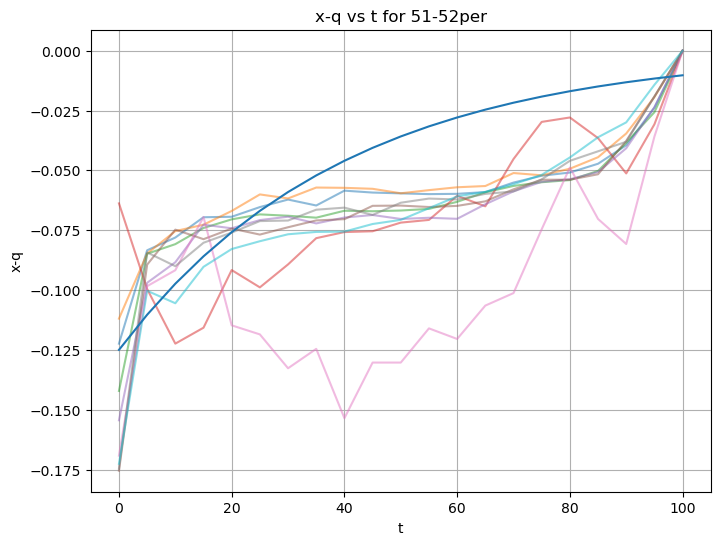

In [514]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 105, 5)
for i in range(30,40):
    y = np.mean(split_list[i][0:21,:], axis=1)
    plt.plot(t,y,alpha=0.5)

x = -0.125*np.exp(-0.025*t)
plt.plot(t,x)
plt.xlabel("t")
plt.ylabel("x-q")
plt.title("x-q vs t for 51-52per")
plt.grid(True)
plt.show()

In [533]:
variance = np.array([np.var(split_list[i][0:21,:], axis=1) for i in range(70)])
time_var = variance.T

print(time_var.shape)

(21, 70)


/home/mori/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/mori/.local/lib/python3.10/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/mori/.local/lib/python3.10/site-packages/numpy/core/_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


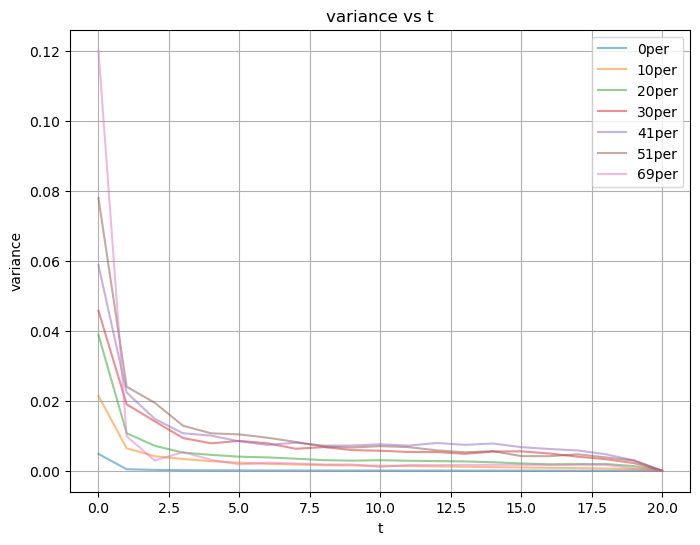

In [554]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 21, 1)

y = time_var[:,0]
plt.plot(t,y,alpha=0.5, label=f"{0}per")
y = time_var[:,10]
plt.plot(t,y,alpha=0.5, label=f"{10}per")
y = time_var[:,20]
plt.plot(t,y,alpha=0.5, label=f"{20}per")
y = time_var[:,30]
plt.plot(t,y,alpha=0.5, label=f"{30}per")
y = time_var[:,41]
plt.plot(t,y,alpha=0.5, label=f"{41}per")
y = time_var[:,51]
plt.plot(t,y,alpha=0.5, label=f"{51}per")
y = time_var[:,69]
plt.plot(t,y,alpha=0.5, label=f"{69}per")

plt.xlabel("t")
plt.ylabel("variance")
plt.title("variance vs t")
plt.grid(True)
plt.legend()
plt.show()
